In [72]:
import os
import random
from collections import defaultdict, deque

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

from scipy.spatial import cKDTree
from scipy.interpolate import splprep, splev

from skimage.morphology import skeletonize

from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from tqdm.auto import tqdm

In [73]:
DATASET_ROOT = "/kaggle/input/datasets/roshsrid/tamil-character-corpus"
def find_numbered_root(base):
    for root, dirs, _ in os.walk(base):
        if all(str(i) in dirs for i in [1, 2, 3]):
            return root

    raise FileNotFoundError(
        f"Could not find numbered character folders under {base}"
    )


NUMBERED_ROOT = find_numbered_root(DATASET_ROOT)

print("Using dataset root:", NUMBERED_ROOT)

Using dataset root: /kaggle/input/datasets/roshsrid/tamil-character-corpus/tamil-characters


In [74]:
VOWELS = ["\u0b85", "\u0b86", "\u0b87", "\u0b88", "\u0b89", "\u0b8a",
          "\u0b8e", "\u0b8f", "\u0b90", "\u0b92", "\u0b93", "\u0b94"]
# அ ஆ இ ஈ உ ஊ எ ஏ ஐ ஒ ஓ ஔ

CONSONANTS_BASE = ["\u0b95\u0bcd", "\u0b99\u0bcd", "\u0b9a\u0bcd", "\u0b9e\u0bcd",
                   "\u0b9f\u0bcd", "\u0ba3\u0bcd", "\u0ba4\u0bcd", "\u0ba8\u0bcd",
                   "\u0baa\u0bcd", "\u0bae\u0bcd", "\u0baf\u0bcd", "\u0bb0\u0bcd",
                   "\u0bb2\u0bcd", "\u0bb5\u0bcd", "\u0bb4\u0bcd", "\u0bb3\u0bcd",
                   "\u0bb1\u0bcd", "\u0ba9\u0bcd"]
# க் ங் ச் ஞ் ட் ண் த் ந் ப் ம் ய் ர் ல் வ் ழ் ள் ற் ன்

FOLDER_TO_CHAR = {}
for i, ch in enumerate(VOWELS, start=1):
    FOLDER_TO_CHAR[i] = ch
for i, ch in enumerate(CONSONANTS_BASE, start=13):
    FOLDER_TO_CHAR[i] = ch

TARGET_FOLDERS = list(FOLDER_TO_CHAR.keys())
print(f"{len(TARGET_FOLDERS)} target classes:", FOLDER_TO_CHAR)

30 target classes: {1: 'அ', 2: 'ஆ', 3: 'இ', 4: 'ஈ', 5: 'உ', 6: 'ஊ', 7: 'எ', 8: 'ஏ', 9: 'ஐ', 10: 'ஒ', 11: 'ஓ', 12: 'ஔ', 13: 'க்', 14: 'ங்', 15: 'ச்', 16: 'ஞ்', 17: 'ட்', 18: 'ண்', 19: 'த்', 20: 'ந்', 21: 'ப்', 22: 'ம்', 23: 'ய்', 24: 'ர்', 25: 'ல்', 26: 'வ்', 27: 'ழ்', 28: 'ள்', 29: 'ற்', 30: 'ன்'}


In [75]:
TARGET_FOLDERS = sorted(FOLDER_TO_CHAR.keys())

print("Number of classes:", len(TARGET_FOLDERS))

Number of classes: 30


In [76]:
for fnum in TARGET_FOLDERS:

    folder_path = os.path.join(
        NUMBERED_ROOT,
        str(fnum)
    )

    images = sorted([
        f for f in os.listdir(folder_path)
        if f.lower().endswith(
            (".png", ".jpg", ".jpeg", ".bmp")
        )
    ])

    print(
        f"Class {fnum}: "
        f"{len(images)} images"
    )

Class 1: 100 images
Class 2: 100 images
Class 3: 100 images
Class 4: 100 images
Class 5: 100 images
Class 6: 100 images
Class 7: 100 images
Class 8: 100 images
Class 9: 100 images
Class 10: 100 images
Class 11: 100 images
Class 12: 100 images
Class 13: 100 images
Class 14: 100 images
Class 15: 100 images
Class 16: 100 images
Class 17: 100 images
Class 18: 100 images
Class 19: 100 images
Class 20: 100 images
Class 21: 100 images
Class 22: 100 images
Class 23: 100 images
Class 24: 100 images
Class 25: 100 images
Class 26: 100 images
Class 27: 100 images
Class 28: 100 images
Class 29: 100 images
Class 30: 100 images


In [77]:
SEED = 42

split = {}

for fnum in TARGET_FOLDERS:

    folder_path = os.path.join(
        NUMBERED_ROOT,
        str(fnum)
    )

    images = sorted([
        os.path.join(folder_path, f)
        for f in os.listdir(folder_path)
        if f.lower().endswith(
            (".png", ".jpg", ".jpeg", ".bmp")
        )
    ])

    # Independent random generator
    rng = random.Random(SEED + fnum)

    rng.shuffle(images)

    train_images = images[:70]
    test_images = images[70:]

    split[fnum] = {
        "train": train_images,
        "test": test_images
    }

print("Deterministic split completed.")

Deterministic split completed.


In [78]:
def preprocess(img_path, target_size=300):

    img = cv2.imread(
        img_path,
        cv2.IMREAD_GRAYSCALE
    )

    if img is None:
        raise ValueError(
            f"Could not read image: {img_path}"
        )

    # 1. Denoising
    img = cv2.medianBlur(img, 3)

    # 2. Otsu threshold
    _, binary = cv2.threshold(
        img,
        0,
        255,
        cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    # 3. Find foreground bounding box
    coords = cv2.findNonZero(binary)

    if coords is None:
        return np.zeros(
            (target_size, target_size),
            dtype=np.uint8
        )

    x, y, w, h = cv2.boundingRect(coords)

    # 4. Crop around character
    cropped = binary[y:y+h, x:x+w]

    # 5. Preserve aspect ratio
    scale = min(
        (target_size * 0.85) / w,
        (target_size * 0.85) / h
    )

    new_w = max(
        1,
        int(w * scale)
    )

    new_h = max(
        1,
        int(h * scale)
    )

    resized = cv2.resize(
        cropped,
        (new_w, new_h),
        interpolation=cv2.INTER_LINEAR
    )

    # 6. Center on canvas
    canvas = np.zeros(
        (target_size, target_size),
        dtype=np.uint8
    )

    x_offset = (
        target_size - new_w
    ) // 2

    y_offset = (
        target_size - new_h
    ) // 2

    canvas[
        y_offset:y_offset + new_h,
        x_offset:x_offset + new_w
    ] = resized

    # 7. NEW: bridge tiny gaps
    kernel = np.ones(
        (3, 3),
        np.uint8
    )

    canvas = cv2.morphologyEx(
        canvas,
        cv2.MORPH_CLOSE,
        kernel,
        iterations=1
    )

    return canvas

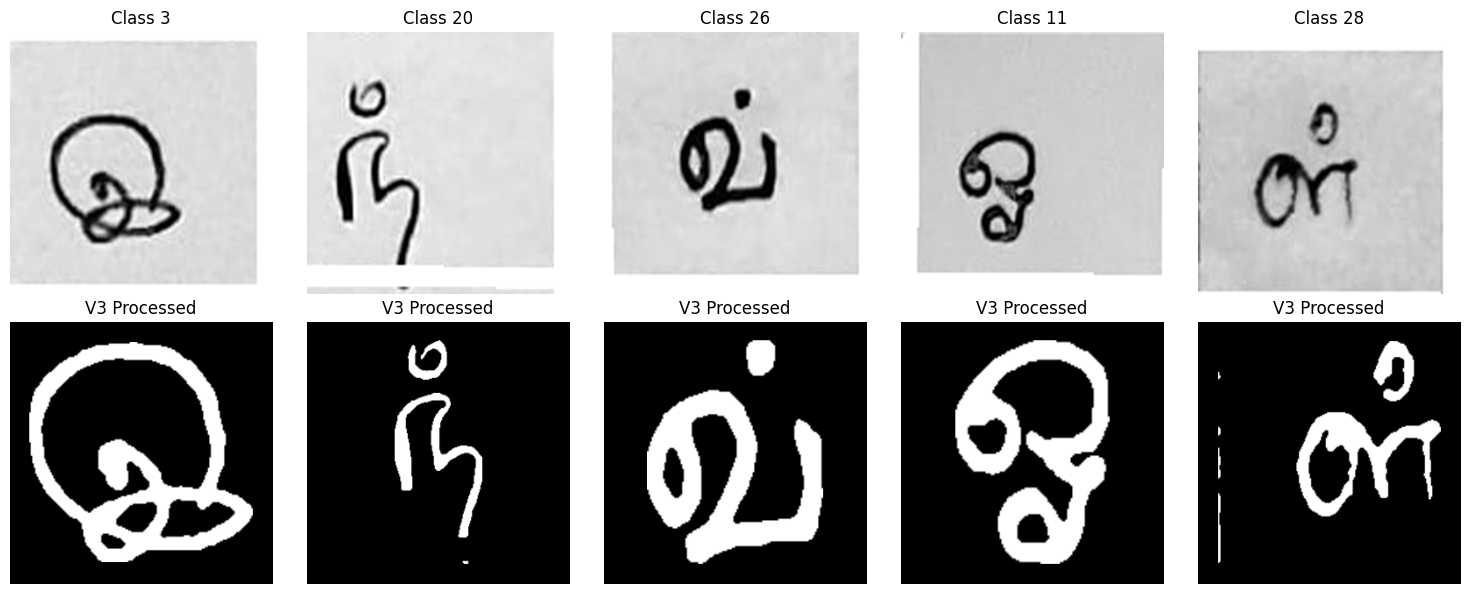

In [79]:
fig, axes = plt.subplots(
    2,
    5,
    figsize=(15, 6)
)

sample_folders = random.sample(
    TARGET_FOLDERS,
    5
)

for col, fnum in enumerate(sample_folders):

    path = split[fnum]["train"][0]

    raw = cv2.imread(
        path,
        cv2.IMREAD_GRAYSCALE
    )

    processed = preprocess(path)

    axes[0, col].imshow(
        raw,
        cmap="gray"
    )

    axes[0, col].set_title(
        f"Class {fnum}"
    )

    axes[0, col].axis("off")

    axes[1, col].imshow(
        processed,
        cmap="gray"
    )

    axes[1, col].set_title(
        "V3 Processed"
    )

    axes[1, col].axis("off")

plt.tight_layout()
plt.show()

In [80]:
def skeleton_points(binary):

    skeleton = skeletonize(
        binary > 0
    )

    y, x = np.where(skeleton)

    points = np.column_stack(
        (x, y)
    )

    return skeleton, points

In [81]:
def order_skeleton_path(
    points,
    connect_radius=2.3
):

    if len(points) < 2:
        return np.array(points)

    pts = np.array(
        points,
        dtype=np.float64
    )

    # Build graph
    tree = cKDTree(pts)

    pairs = tree.query_pairs(
        r=connect_radius
    )

    adj = defaultdict(list)

    for i, j in pairs:
        adj[i].append(j)
        adj[j].append(i)

    # Find connected components
    visited = set()
    components = []

    for i in range(len(pts)):

        if i in visited:
            continue

        component = []

        stack = [i]

        visited.add(i)

        while stack:

            current = stack.pop()

            component.append(current)

            for neighbor in adj[current]:

                if neighbor not in visited:

                    visited.add(neighbor)

                    stack.append(neighbor)

        components.append(component)

    # Use largest component
    largest_component = max(
        components,
        key=len
    )

    component_set = set(
        largest_component
    )

    local_map = {
        old_idx: new_idx
        for new_idx, old_idx
        in enumerate(largest_component)
    }

    local_points = pts[
        largest_component
    ]

    local_adj = defaultdict(list)

    for old_idx in largest_component:

        new_idx = local_map[old_idx]

        for neighbor in adj[old_idx]:

            if neighbor in component_set:

                local_adj[new_idx].append(
                    local_map[neighbor]
                )

    # Find endpoints
    endpoints = [
        i
        for i in range(len(local_points))
        if len(local_adj[i]) == 1
    ]

    start = (
        endpoints[0]
        if endpoints
        else 0
    )

    # Efficient BFS
    def bfs_farthest(source):

        visited = {
            source: 0
        }

        queue = deque([source])

        farthest = source

        while queue:

            current = queue.popleft()

            for neighbor in local_adj[current]:

                if neighbor not in visited:

                    visited[neighbor] = (
                        visited[current] + 1
                    )

                    queue.append(
                        neighbor
                    )

                    if (
                        visited[neighbor]
                        > visited[farthest]
                    ):
                        farthest = neighbor

        return farthest

    far1 = bfs_farthest(start)

    far2 = bfs_farthest(far1)

    # Reconstruct path
    parent = {
        far1: None
    }

    queue = deque([far1])

    while queue:

        current = queue.popleft()

        if current == far2:
            break

        for neighbor in local_adj[current]:

            if neighbor not in parent:

                parent[neighbor] = current

                queue.append(neighbor)

    path_indices = []

    current = far2

    while current is not None:

        path_indices.append(
            current
        )

        current = parent.get(
            current
        )

    path_indices.reverse()

    ordered = local_points[
        path_indices
    ]

    return ordered

In [82]:
def canonical_order(points):

    if len(points) < 2:
        return points

    start = points[0]
    end = points[-1]

    # Start at topmost endpoint.
    # If same height, start at leftmost.
    if (
        (start[1], start[0])
        >
        (end[1], end[0])
    ):

        points = points[::-1]

    return points

In [83]:
def reduce_points(
    points,
    epsilon=1.0
):

    if len(points) < 2:
        return points

    contour = np.array(
        points,
        dtype=np.float32
    ).reshape(
        -1,
        1,
        2
    )

    reduced = cv2.approxPolyDP(
        contour,
        epsilon,
        False
    )

    return reduced.reshape(
        -1,
        2
    )

In [84]:
N_SAMPLE_POINTS = 80
def fit_bspline_feature(
    points,
    n_samples=N_SAMPLE_POINTS
):

    pts = np.array(
        points,
        dtype=np.float64
    )

    if len(pts) < 4:
        return None

    x = pts[:, 0]
    y = pts[:, 1]

    try:

        tck, _ = splprep(
            [x, y],
            s=len(pts),
            k=min(3, len(pts) - 1)
        )

        u = np.linspace(
            0,
            1,
            n_samples
        )

        x_new, y_new = splev(
            u,
            tck
        )

        curve = np.column_stack(
            (x_new, y_new)
        )

    except Exception:

        return None

    # Translation normalization
    curve = (
        curve
        - np.mean(
            curve,
            axis=0
        )
    )

    # Scale normalization
    norm = np.linalg.norm(
        curve
    )

    if norm > 0:
        curve = curve / norm

    return curve.flatten()

In [85]:
def extract_feature(
    img_path,
    epsilon=1.0
):

    binary = preprocess(img_path)

    skeleton, points = skeleton_points(
        binary
    )

    if len(points) < 4:
        return None

    ordered = order_skeleton_path(
        points
    )

    if len(ordered) < 4:
        return None

    ordered = canonical_order(
        ordered
    )

    reduced = reduce_points(
        ordered,
        epsilon=epsilon
    )

    if len(reduced) < 4:
        return None

    feature = fit_bspline_feature(
        reduced
    )

    return feature

In [86]:
for fnum in random.sample(
    TARGET_FOLDERS,
    5
):

    path = split[fnum]["train"][0]

    binary = preprocess(path)

    skeleton, points = skeleton_points(
        binary
    )

    ordered = order_skeleton_path(
        points
    )

    coverage = (
        len(ordered)
        / len(points)
        if len(points) > 0
        else 0
    )

    print(
        f"Class {fnum}: "
        f"Skeleton={len(points)}, "
        f"Path={len(ordered)}, "
        f"Coverage={coverage:.2%}"
    )

Class 13: Skeleton=731, Path=119, Coverage=16.28%
Class 1: Skeleton=960, Path=206, Coverage=21.46%
Class 10: Skeleton=841, Path=390, Coverage=46.37%
Class 14: Skeleton=810, Path=278, Coverage=34.32%
Class 25: Skeleton=440, Path=155, Coverage=35.23%


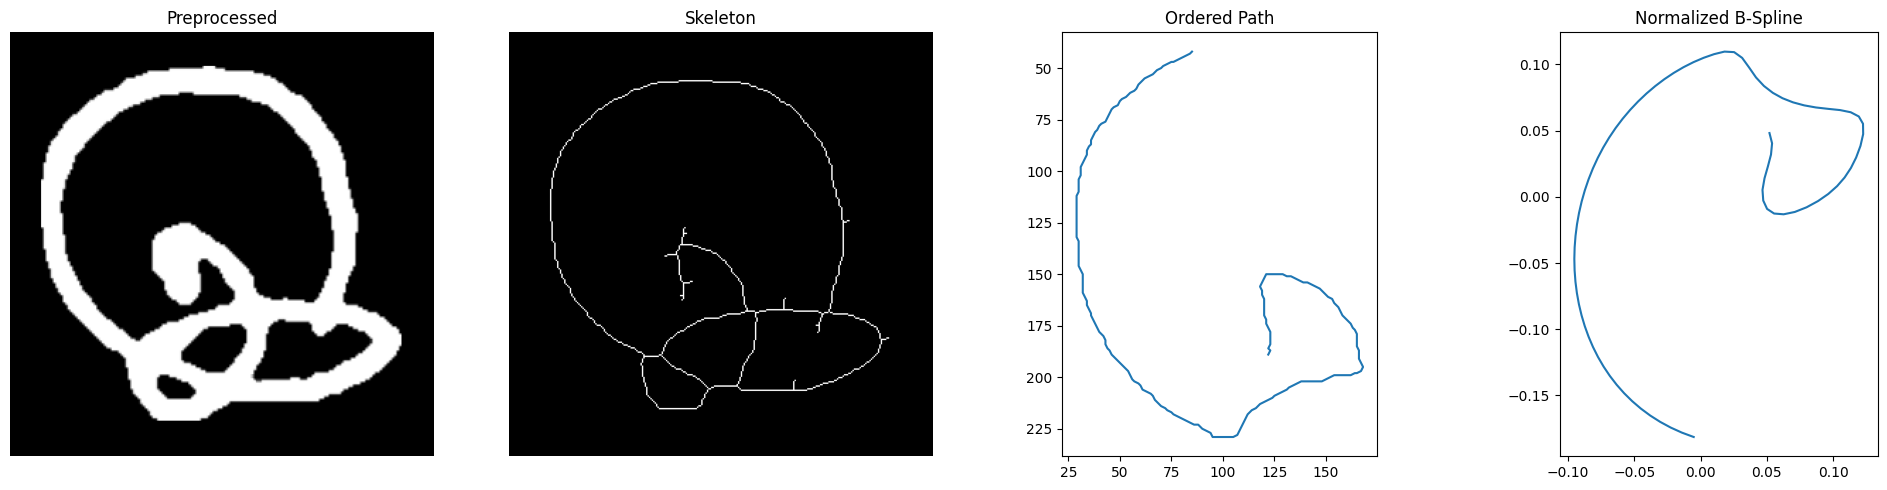

In [87]:
fnum = random.choice(
    TARGET_FOLDERS
)

path = split[fnum]["train"][0]

binary = preprocess(path)

skeleton, points = skeleton_points(
    binary
)

ordered = order_skeleton_path(
    points
)

ordered = canonical_order(
    ordered
)

reduced = reduce_points(
    ordered,
    epsilon=1.0
)

feature = fit_bspline_feature(
    reduced
)

fig, axes = plt.subplots(
    1,
    4,
    figsize=(20, 5)
)

axes[0].imshow(
    binary,
    cmap="gray"
)

axes[0].set_title(
    "Preprocessed"
)

axes[0].axis("off")

axes[1].imshow(
    skeleton,
    cmap="gray"
)

axes[1].set_title(
    "Skeleton"
)

axes[1].axis("off")

if len(ordered) > 0:

    axes[2].plot(
        ordered[:, 0],
        ordered[:, 1]
    )

    axes[2].invert_yaxis()
    axes[2].set_aspect("equal")

axes[2].set_title(
    "Ordered Path"
)

if feature is not None:

    curve = feature.reshape(
        -1,
        2
    )

    axes[3].plot(
        curve[:, 0],
        curve[:, 1]
    )

    axes[3].set_aspect("equal")

axes[3].set_title(
    "Normalized B-Spline"
)

plt.tight_layout()
plt.show()

In [88]:
def build_feature_library(
    split,
    epsilon=1.0
):

    X = []
    y = []
    failed = []

    for fnum in tqdm(
        TARGET_FOLDERS,
        desc="Building training features"
    ):

        for path in split[fnum]["train"]:

            feature = extract_feature(
                path,
                epsilon
            )

            if feature is None:

                failed.append(path)

                continue

            X.append(feature)

            y.append(
                FOLDER_TO_CHAR[fnum]
            )

    return (
        np.array(X),
        np.array(y),
        failed
    )

In [89]:
X_train, y_train, failed_train = (
    build_feature_library(split)
)

print(
    "Training shape:",
    X_train.shape
)

print(
    "Failed:",
    len(failed_train)
)

Building training features:   0%|          | 0/30 [00:00<?, ?it/s]

Training shape: (2059, 160)
Failed: 41


In [91]:
def diagnose_feature(img_path, epsilon=1.0):

    binary = preprocess(img_path)

    skeleton, points = skeleton_points(binary)

    if len(points) < 4:
        return "Too few skeleton points"

    ordered = order_skeleton_path(points)

    if len(ordered) < 4:
        return "Too few ordered path points"

    ordered = canonical_order(ordered)

    reduced = reduce_points(
        ordered,
        epsilon=epsilon
    )

    if len(reduced) < 4:
        return "Too few reduced points"

    feature = fit_bspline_feature(reduced)

    if feature is None:
        return "B-spline fitting failed"

    return "Success"

In [92]:
def build_test_set(
    split,
    epsilon=1.0
):

    X = []
    y = []
    failed = []

    for fnum in tqdm(
        TARGET_FOLDERS,
        desc="Building test features"
    ):

        for path in split[fnum]["test"]:

            feature = extract_feature(
                path,
                epsilon
            )

            if feature is None:

                failed.append(path)

                continue

            X.append(feature)

            y.append(
                FOLDER_TO_CHAR[fnum]
            )

    return (
        np.array(X),
        np.array(y),
        failed
    )

In [93]:
X_test, y_test, failed_test = (
    build_test_set(split)
)

print(
    "Test shape:",
    X_test.shape
)

print(
    "Failed:",
    len(failed_test)
)

Building test features:   0%|          | 0/30 [00:00<?, ?it/s]

Test shape: (888, 160)
Failed: 12


In [94]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

In [96]:
clf = KNeighborsClassifier(
    n_neighbors=5,
    metric="euclidean",
    weights="distance"
)

clf.fit(
    X_train_scaled,
    y_train
)

y_pred = clf.predict(
    X_test_scaled
)

accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    f"Version 3 Baseline Accuracy: "
    f"{accuracy * 100:.2f}%"
)

Version 3 Baseline Accuracy: 61.15%


In [97]:
train_pred = clf.predict(
    X_train_scaled
)

train_accuracy = accuracy_score(
    y_train,
    train_pred
)

print(
    f"Training Accuracy: "
    f"{train_accuracy * 100:.2f}%"
)

print(
    f"Test Accuracy: "
    f"{accuracy * 100:.2f}%"
)

Training Accuracy: 100.00%
Test Accuracy: 61.15%


In [98]:
print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           அ       0.39      0.45      0.42        29
           ஆ       0.75      0.50      0.60        30
           இ       0.65      0.50      0.57        30
           ஈ       0.55      0.79      0.65        28
           உ       0.74      0.69      0.71        29
           ஊ       0.81      0.43      0.57        30
           எ       0.54      0.52      0.53        29
           ஏ       0.58      0.70      0.64        30
           ஐ       0.74      0.47      0.57        30
           ஒ       0.36      0.30      0.33        30
           ஓ       0.64      0.30      0.41        30
           ஔ       0.23      0.17      0.19        30
          க்       0.37      0.23      0.29        30
          ங்       0.78      0.72      0.75        29
          ச்       0.42      0.69      0.52        29
          ஞ்       0.75      0.60      0.67        30
          ட்       0.74      1.00      0.85        29
          ண்       0.71    

In [99]:
results = []

for k in [1, 3, 5, 7, 9, 11]:

    model = KNeighborsClassifier(
        n_neighbors=k,
        metric="euclidean",
        weights="distance"
    )

    model.fit(
        X_train_scaled,
        y_train
    )

    predictions = model.predict(
        X_test_scaled
    )

    acc = accuracy_score(
        y_test,
        predictions
    )

    results.append(
        (k, acc)
    )

    print(
        f"K={k}: "
        f"{acc * 100:.2f}%"
    )

K=1: 60.25%
K=3: 60.25%
K=5: 61.15%
K=7: 61.04%
K=9: 61.37%
K=11: 59.46%


In [100]:
best_k, best_accuracy = max(
    results,
    key=lambda x: x[1]
)

print(
    f"\nBest K: {best_k}"
)

print(
    f"Best Accuracy: "
    f"{best_accuracy * 100:.2f}%"
)


Best K: 9
Best Accuracy: 61.37%


In [101]:
final_clf = KNeighborsClassifier(
    n_neighbors=best_k,
    metric="euclidean",
    weights="distance"
)

final_clf.fit(
    X_train_scaled,
    y_train
)

final_pred = final_clf.predict(
    X_test_scaled
)

final_accuracy = accuracy_score(
    y_test,
    final_pred
)

print(
    f"FINAL VERSION 3 ACCURACY: "
    f"{final_accuracy * 100:.2f}%"
)

FINAL VERSION 3 ACCURACY: 61.37%


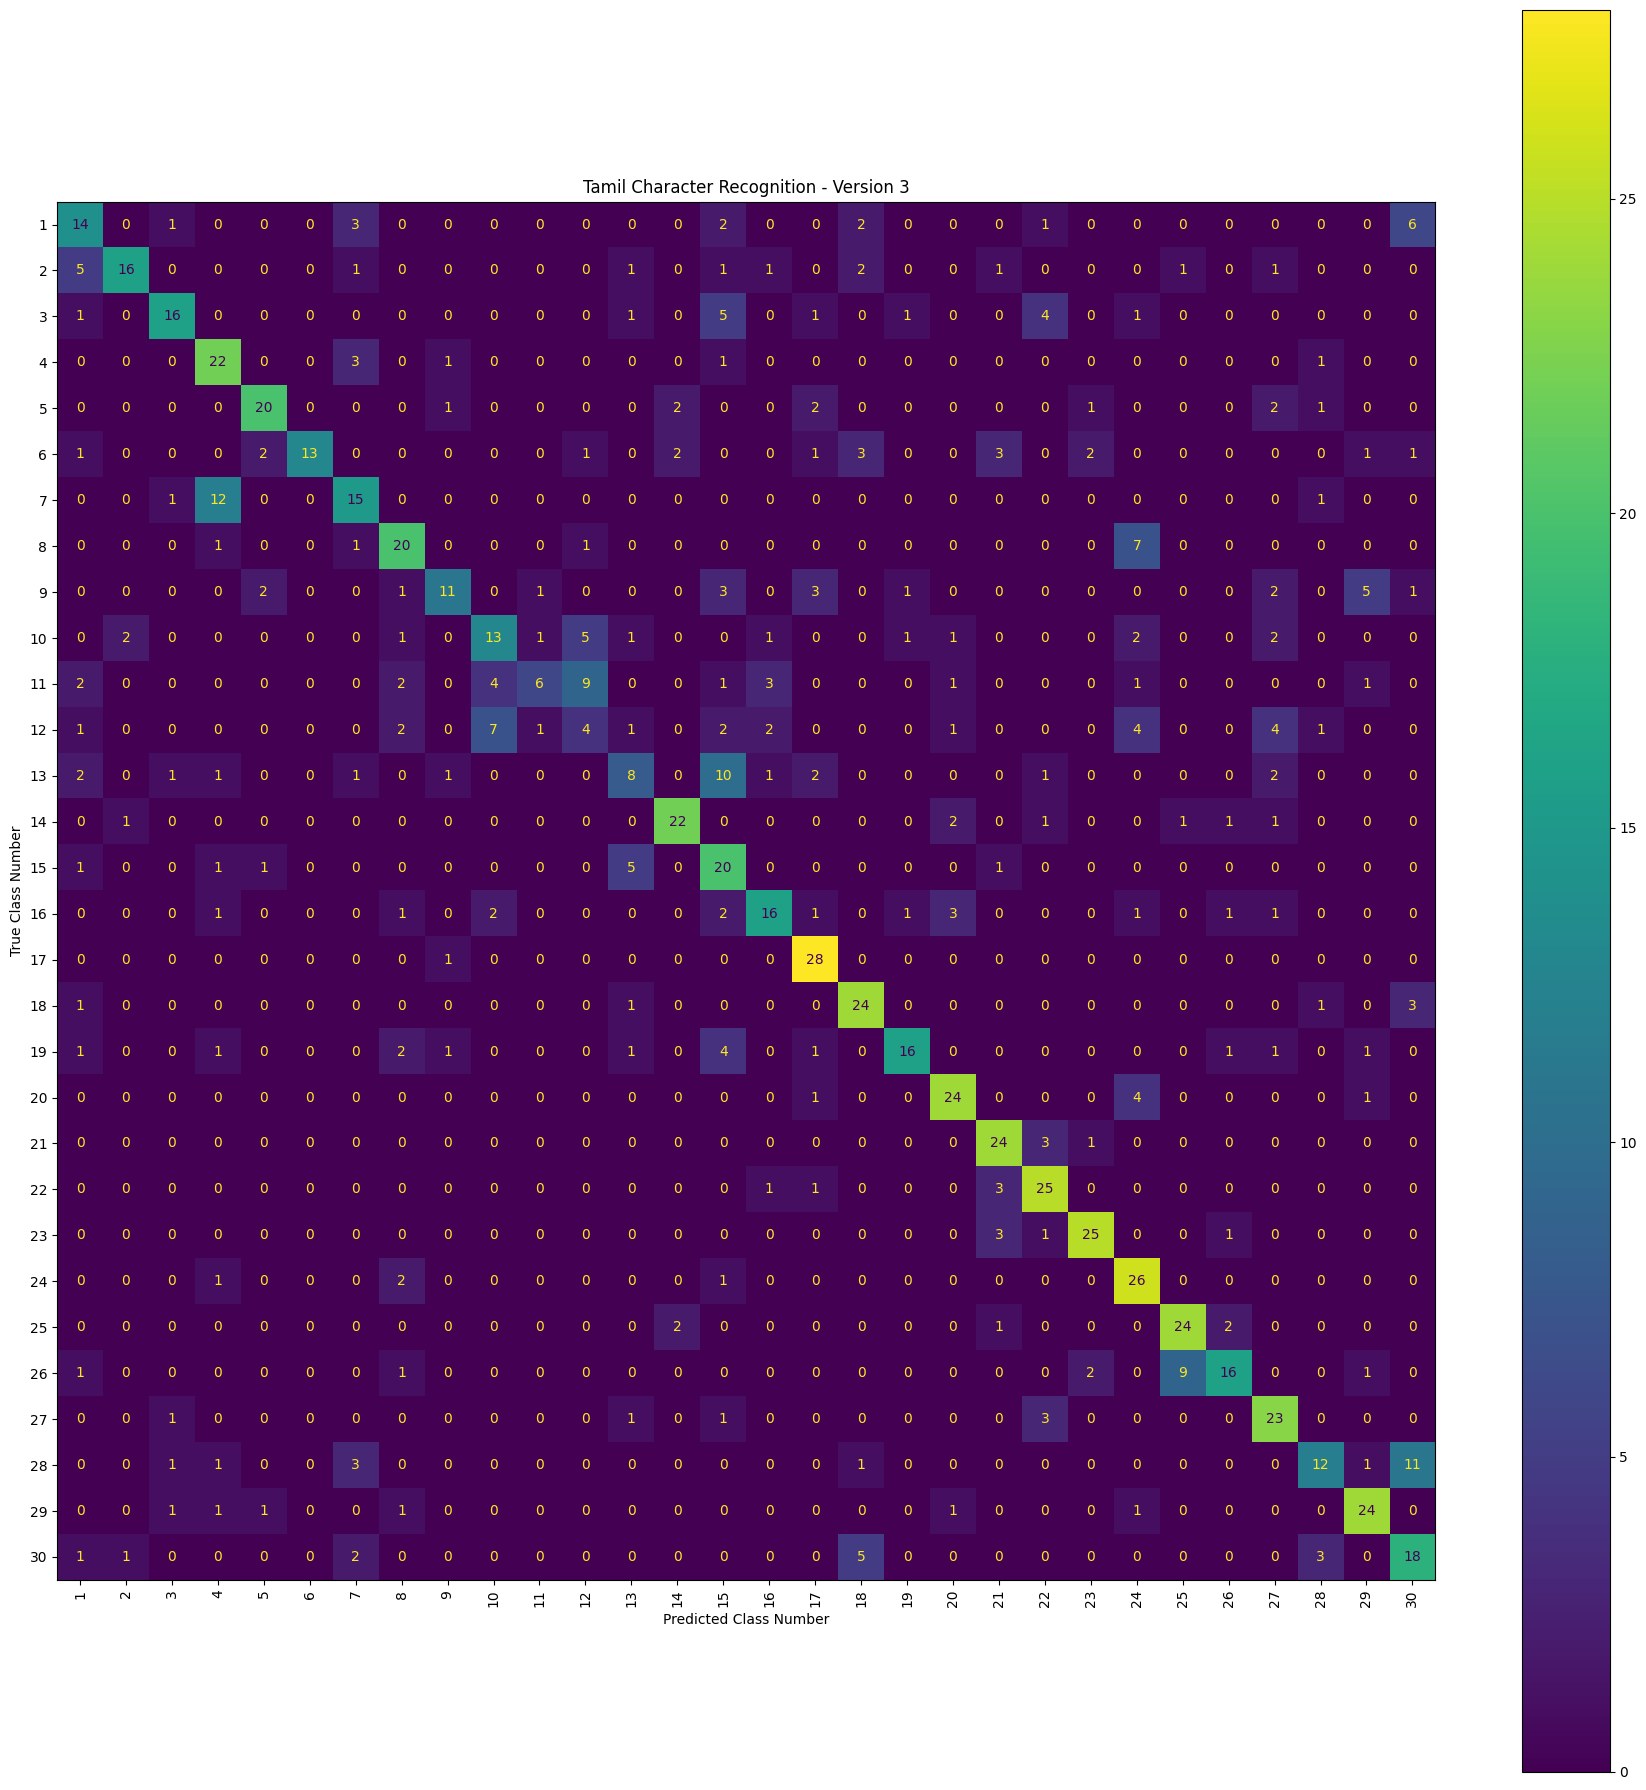

In [102]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Use folder/class numbers instead of Tamil characters
labels = list(range(1, 31))

# Convert Tamil character labels back to class numbers
CHAR_TO_FOLDER = {
    char: fnum
    for fnum, char in FOLDER_TO_CHAR.items()
}

y_test_num = np.array([
    CHAR_TO_FOLDER[label]
    for label in y_test
])

final_pred_num = np.array([
    CHAR_TO_FOLDER[label]
    for label in final_pred
])

cm = confusion_matrix(
    y_test_num,
    final_pred_num,
    labels=labels
)

fig, ax = plt.subplots(figsize=(18, 18))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

disp.plot(
    ax=ax,
    xticks_rotation=90,
    values_format="d",
    colorbar=True
)

plt.title("Tamil Character Recognition - Version 3")
plt.xlabel("Predicted Class Number")
plt.ylabel("True Class Number")

plt.tight_layout()
plt.show()

In [103]:
print("clf exists:", "clf" in globals())
print("final_clf exists:", "final_clf" in globals())
print("X_test exists:", "X_test" in globals())
print("X_test_scaled exists:", "X_test_scaled" in globals())
print("scaler exists:", "scaler" in globals())

clf exists: True
final_clf exists: True
X_test exists: True
X_test_scaled exists: True
scaler exists: True


In [104]:
from sklearn.metrics import accuracy_score

vision_pred = clf.predict(X_test_scaled)

vision_accuracy = accuracy_score(
    y_test,
    vision_pred
)

print(
    f"Vision Accuracy: "
    f"{vision_accuracy * 100:.2f}%"
)

Vision Accuracy: 61.15%


In [105]:
final_clf = clf

print("Vision classifier ready")
print("Classes:", len(FOLDER_TO_CHAR))
print("Vision baseline accuracy:", f"{vision_accuracy * 100:.2f}%")

Vision classifier ready
Classes: 30
Vision baseline accuracy: 61.15%


In [106]:
TOP_K = 3

probs = final_clf.predict_proba(X_test_scaled)

top3_indices = np.argsort(
    probs,
    axis=1
)[:, -TOP_K:][:, ::-1]

top3_probs = np.take_along_axis(
    probs,
    top3_indices,
    axis=1
)

print("Top-3 predictions generated")

Top-3 predictions generated


In [107]:
classes = final_clf.classes_

def get_top_candidates(
    sample_index,
    top_k=3
):

    candidates = []

    for rank in range(top_k):

        class_index = top3_indices[
            sample_index,
            rank
        ]

        character = classes[
            class_index
        ]

        confidence = top3_probs[
            sample_index,
            rank
        ]

        candidates.append({
            "rank": rank + 1,
            "character": character,
            "confidence": float(confidence)
        })

    return candidates

In [109]:
CHAR_TO_FOLDER = {
    char: folder
    for folder, char in FOLDER_TO_CHAR.items()
}

In [110]:
sample_index = 0

print("True class number:",
      CHAR_TO_FOLDER[y_test[sample_index]]
)

print("\nTop candidates:")

for candidate in get_top_candidates(sample_index):

    class_num = CHAR_TO_FOLDER[
        candidate["character"]
    ]

    print(
        f"Rank {candidate['rank']}: "
        f"Class {class_num} | "
        f"Confidence: {candidate['confidence']:.4f}"
    )

True class number: 1

Top candidates:
Rank 1: Class 1 | Confidence: 0.8029
Rank 2: Class 19 | Confidence: 0.1971
Rank 3: Class 28 | Confidence: 0.0000


In [111]:
top1_correct = 0
top3_correct = 0

for i in range(len(y_test)):

    candidates = get_top_candidates(
        i,
        top_k=3
    )

    predicted_chars = [
        candidate["character"]
        for candidate in candidates
    ]

    if y_test[i] == predicted_chars[0]:
        top1_correct += 1

    if y_test[i] in predicted_chars:
        top3_correct += 1


top1_accuracy = (
    top1_correct / len(y_test)
)

top3_accuracy = (
    top3_correct / len(y_test)
)

print(
    f"Top-1 Accuracy: "
    f"{top1_accuracy * 100:.2f}%"
)

print(
    f"Top-3 Accuracy: "
    f"{top3_accuracy * 100:.2f}%"
)

Top-1 Accuracy: 61.15%
Top-3 Accuracy: 80.97%


In [112]:
# Number of neighbors used by the classifier
K = final_clf.n_neighbors

# Get distances and indices of the K nearest neighbors
distances, neighbor_indices = final_clf.kneighbors(
    X_test_scaled,
    n_neighbors=K
)

print("Distance matrix shape:", distances.shape)
print("Number of neighbors:", K)

# Inspect one sample
sample_index = 0

print("\nSample:", sample_index)
print("True class:", CHAR_TO_FOLDER[y_test[sample_index]])

print("\nNeighbor distances:")
print(distances[sample_index])

Distance matrix shape: (888, 5)
Number of neighbors: 5

Sample: 0
True class: 1

Neighbor distances:
[3.19901689 3.37443928 3.41329657 3.45593373 3.6161472 ]


In [113]:
def get_ambiguity_info(sample_index):

    # Top-1 and Top-2 probabilities
    top1_prob = top3_probs[sample_index, 0]
    top2_prob = top3_probs[sample_index, 1]

    # Probability gap
    confidence_gap = top1_prob - top2_prob

    # Nearest-neighbor distance
    nearest_distance = distances[sample_index, 0]

    # Average distance of K neighbors
    mean_distance = np.mean(
        distances[sample_index]
    )

    # Predicted class number
    predicted_char = classes[
        top3_indices[sample_index, 0]
    ]

    predicted_class = CHAR_TO_FOLDER[
        predicted_char
    ]

    return {
        "predicted_class": predicted_class,
        "top1_probability": float(top1_prob),
        "top2_probability": float(top2_prob),
        "confidence_gap": float(confidence_gap),
        "nearest_distance": float(nearest_distance),
        "mean_neighbor_distance": float(mean_distance)
    }


# Test on the first sample
sample_index = 0

info = get_ambiguity_info(sample_index)

for key, value in info.items():

    if isinstance(value, float):

        print(f"{key}: {value:.4f}")

    else:

        print(f"{key}: {value}")

predicted_class: 1
top1_probability: 0.8029
top2_probability: 0.1971
confidence_gap: 0.6057
nearest_distance: 3.1990
mean_neighbor_distance: 3.4118


In [114]:
def categorize_prediction(sample_index):

    info = get_ambiguity_info(sample_index)

    top1_prob = info["top1_probability"]
    gap = info["confidence_gap"]

    # High confidence:
    # strong Top-1 probability and clear separation
    if top1_prob >= 0.80 and gap >= 0.40:

        return "HIGH"

    # Medium confidence:
    # reasonably likely, but still somewhat ambiguous
    elif top1_prob >= 0.60 and gap >= 0.20:

        return "MEDIUM"

    # Low confidence:
    # ambiguous prediction
    else:

        return "LOW"


confidence_groups = {
    "HIGH": [],
    "MEDIUM": [],
    "LOW": []
}

for i in range(len(y_test)):

    category = categorize_prediction(i)

    confidence_groups[category].append(i)


for category in ["HIGH", "MEDIUM", "LOW"]:

    count = len(confidence_groups[category])

    percentage = (
        count / len(y_test) * 100
    )

    print(
        f"{category}: "
        f"{count} samples "
        f"({percentage:.2f}%)"
    )

HIGH: 339 samples (38.18%)
MEDIUM: 197 samples (22.18%)
LOW: 352 samples (39.64%)


In [115]:
group_results = {}

for category in ["HIGH", "MEDIUM", "LOW"]:

    indices = confidence_groups[category]

    correct = 0

    for i in indices:

        predicted_char = classes[
            top3_indices[i, 0]
        ]

        if predicted_char == y_test[i]:
            correct += 1

    accuracy = (
        correct / len(indices)
        if len(indices) > 0
        else 0
    )

    group_results[category] = {
        "samples": len(indices),
        "correct": correct,
        "accuracy": accuracy
    }

    print(
        f"{category}: "
        f"{correct}/{len(indices)} correct | "
        f"Accuracy = {accuracy * 100:.2f}%"
    )

HIGH: 289/339 correct | Accuracy = 85.25%
MEDIUM: 130/197 correct | Accuracy = 65.99%
LOW: 124/352 correct | Accuracy = 35.23%


In [116]:
for category in ["HIGH", "MEDIUM", "LOW"]:

    indices = confidence_groups[category]

    top3_correct = 0

    for i in indices:

        candidate_chars = [
            classes[class_index]
            for class_index in top3_indices[i]
        ]

        if y_test[i] in candidate_chars:
            top3_correct += 1

    top3_accuracy_group = (
        top3_correct / len(indices)
        if len(indices) > 0
        else 0
    )

    print(
        f"{category}: "
        f"Top-3 = {top3_correct}/{len(indices)} | "
        f"Accuracy = {top3_accuracy_group * 100:.2f}%"
    )

HIGH: Top-3 = 302/339 | Accuracy = 89.09%
MEDIUM: Top-3 = 171/197 | Accuracy = 86.80%
LOW: Top-3 = 246/352 | Accuracy = 69.89%


In [117]:
def get_slm_candidates(sample_index):

    candidates = []

    for rank in range(3):

        class_index = top3_indices[
            sample_index,
            rank
        ]

        character = classes[
            class_index
        ]

        class_number = CHAR_TO_FOLDER[
            character
        ]

        probability = top3_probs[
            sample_index,
            rank
        ]

        candidates.append({
            "rank": rank + 1,
            "class_number": int(class_number),
            "probability": float(probability)
        })

    return candidates

In [118]:
sample_index = 0

candidates = get_slm_candidates(
    sample_index
)

print(
    "True class:",
    CHAR_TO_FOLDER[y_test[sample_index]]
)

print()

for candidate in candidates:

    print(
        f"Rank {candidate['rank']} | "
        f"Class {candidate['class_number']} | "
        f"Probability: "
        f"{candidate['probability']:.4f}"
    )

True class: 1

Rank 1 | Class 1 | Probability: 0.8029
Rank 2 | Class 19 | Probability: 0.1971
Rank 3 | Class 28 | Probability: 0.0000


In [119]:
def build_agent_input(sample_index):

    candidates = get_slm_candidates(
        sample_index
    )

    ambiguity = get_ambiguity_info(
        sample_index
    )

    confidence_group = categorize_prediction(
        sample_index
    )

    return {
        "sample_index": sample_index,
        "confidence_group": confidence_group,

        "vision_prediction": {
            "class_number": ambiguity[
                "predicted_class"
            ],
            "top1_probability": ambiguity[
                "top1_probability"
            ],
            "top2_probability": ambiguity[
                "top2_probability"
            ],
            "confidence_gap": ambiguity[
                "confidence_gap"
            ],
            "nearest_distance": ambiguity[
                "nearest_distance"
            ],
            "mean_neighbor_distance": ambiguity[
                "mean_neighbor_distance"
            ]
        },

        "candidates": candidates
    }

In [120]:
sample_index = 0

agent_input = build_agent_input(
    sample_index
)

print(agent_input)

{'sample_index': 0, 'confidence_group': 'HIGH', 'vision_prediction': {'class_number': 1, 'top1_probability': 0.8028643095976308, 'top2_probability': 0.19713569040236917, 'confidence_gap': 0.6057286191952616, 'nearest_distance': 3.1990168923137823, 'mean_neighbor_distance': 3.411766734477226}, 'candidates': [{'rank': 1, 'class_number': 1, 'probability': 0.8028643095976308}, {'rank': 2, 'class_number': 19, 'probability': 0.19713569040236917}, {'rank': 3, 'class_number': 28, 'probability': 0.0}]}


In [121]:
def route_to_slm(sample_index):

    agent_input = build_agent_input(
        sample_index
    )

    confidence_group = agent_input[
        "confidence_group"
    ]

    if confidence_group == "HIGH":

        action = "ACCEPT_VISION"

    elif confidence_group == "MEDIUM":

        action = "SEND_TO_SLM"

    else:

        action = "SEND_TO_SLM"

    return {
        "action": action,
        "agent_input": agent_input
    }

In [122]:
sample_index = 0

routing_result = route_to_slm(
    sample_index
)

print(
    "Action:",
    routing_result["action"]
)

print(
    "Confidence group:",
    routing_result["agent_input"]["confidence_group"]
)

print(
    "Vision prediction:",
    routing_result["agent_input"]
    ["vision_prediction"]
    ["class_number"]
)

Action: ACCEPT_VISION
Confidence group: HIGH
Vision prediction: 1


In [123]:
# Test one sample from each confidence group

for category in ["HIGH", "MEDIUM", "LOW"]:

    if len(confidence_groups[category]) == 0:
        continue

    sample_index = confidence_groups[category][0]

    result = route_to_slm(sample_index)

    true_class = CHAR_TO_FOLDER[
        y_test[sample_index]
    ]

    vision_class = result["agent_input"][
        "vision_prediction"
    ]["class_number"]

    print("=" * 50)

    print("Sample index:", sample_index)
    print("Confidence group:", category)
    print("Routing action:", result["action"])
    print("True class:", true_class)
    print("Vision prediction:", vision_class)

    print("\nTop-3 candidates:")

    for candidate in result["agent_input"]["candidates"]:

        print(
            f"Rank {candidate['rank']} | "
            f"Class {candidate['class_number']} | "
            f"Probability: {candidate['probability']:.4f}"
        )

Sample index: 0
Confidence group: HIGH
Routing action: ACCEPT_VISION
True class: 1
Vision prediction: 1

Top-3 candidates:
Rank 1 | Class 1 | Probability: 0.8029
Rank 2 | Class 19 | Probability: 0.1971
Rank 3 | Class 28 | Probability: 0.0000
Sample index: 4
Confidence group: MEDIUM
Routing action: SEND_TO_SLM
True class: 1
Vision prediction: 1

Top-3 candidates:
Rank 1 | Class 1 | Probability: 0.6202
Rank 2 | Class 20 | Probability: 0.1993
Rank 3 | Class 29 | Probability: 0.1804
Sample index: 1
Confidence group: LOW
Routing action: SEND_TO_SLM
True class: 1
Vision prediction: 7

Top-3 candidates:
Rank 1 | Class 7 | Probability: 0.5652
Rank 2 | Class 30 | Probability: 0.4348
Rank 3 | Class 28 | Probability: 0.0000


In [124]:
from sklearn.metrics import pairwise_distances

def get_candidate_distance_info(sample_index, top_k=3):

    test_vector = X_test_scaled[sample_index].reshape(1, -1)

    candidates = get_slm_candidates(sample_index)[:top_k]

    enriched_candidates = []

    for candidate in candidates:

        class_number = candidate["class_number"]

        character = FOLDER_TO_CHAR[class_number]

        # Find all training samples belonging
        # to this candidate class
        class_indices = np.where(
            y_train == character
        )[0]

        class_vectors = X_train_scaled[
            class_indices
        ]

        # Distance from test sample to all examples
        # of this candidate class
        class_distances = pairwise_distances(
            test_vector,
            class_vectors,
            metric="euclidean"
        )[0]

        enriched_candidates.append({
            "rank": candidate["rank"],
            "class_number": class_number,
            "probability": candidate["probability"],
            "min_distance": float(
                np.min(class_distances)
            ),
            "mean_distance": float(
                np.mean(class_distances)
            )
        })

    return enriched_candidates

In [125]:
sample_index = 1   # LOW-confidence example

enriched = get_candidate_distance_info(
    sample_index
)

print(
    "True class:",
    CHAR_TO_FOLDER[y_test[sample_index]]
)

print()

for candidate in enriched:

    print(
        f"Rank {candidate['rank']} | "
        f"Class {candidate['class_number']}"
    )

    print(
        f"  Probability: "
        f"{candidate['probability']:.4f}"
    )

    print(
        f"  Minimum distance: "
        f"{candidate['min_distance']:.4f}"
    )

    print(
        f"  Mean class distance: "
        f"{candidate['mean_distance']:.4f}"
    )

    print()

True class: 1

Rank 1 | Class 7
  Probability: 0.5652
  Minimum distance: 1.6434
  Mean class distance: 8.9358

Rank 2 | Class 30
  Probability: 0.4348
  Minimum distance: 1.6091
  Mean class distance: 11.2052

Rank 3 | Class 28
  Probability: 0.0000
  Minimum distance: 3.2567
  Mean class distance: 13.0562



In [126]:
TOP_K_AGENT = 5

top5_indices = np.argsort(
    probs,
    axis=1
)[:, -TOP_K_AGENT:][:, ::-1]

top5_probs = np.take_along_axis(
    probs,
    top5_indices,
    axis=1
)

print("Top-5 candidates generated")
print("Shape:", top5_indices.shape)

Top-5 candidates generated
Shape: (888, 5)


In [127]:
top5_correct = 0

for i in range(len(y_test)):

    candidate_chars = [
        classes[class_index]
        for class_index in top5_indices[i]
    ]

    if y_test[i] in candidate_chars:
        top5_correct += 1


top5_accuracy = (
    top5_correct / len(y_test)
)

print(
    f"Top-5 Accuracy: "
    f"{top5_accuracy * 100:.2f}%"
)

Top-5 Accuracy: 82.77%


In [128]:
!pip install -q transformers accelerate sentencepiece

In [129]:
import torch

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM
)

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch version: 2.10.0+cu128
CUDA available: True


In [130]:
MODEL_NAME = "Qwen/Qwen2.5-0.5B-Instruct"

print("Selected SLM:", MODEL_NAME)

Selected SLM: Qwen/Qwen2.5-0.5B-Instruct


In [131]:
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="auto"
)

print("SLM loaded successfully")

config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

SLM loaded successfully


In [132]:
print("Model device:")

for name, param in model.named_parameters():
    print(param.device)
    break

Model device:
cuda:0


In [133]:
messages = [
    {
        "role": "system",
        "content": (
            "You are a precise validation assistant. "
            "Follow instructions exactly."
        )
    },
    {
        "role": "user",
        "content": (
            "Reply with exactly one word: READY"
        )
    }
]

text = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True
)

inputs = tokenizer(
    text,
    return_tensors="pt"
).to(model.device)

with torch.no_grad():

    outputs = model.generate(
        **inputs,
        max_new_tokens=20,
        do_sample=False
    )

response_tokens = outputs[
    0,
    inputs["input_ids"].shape[1]:
]

response = tokenizer.decode(
    response_tokens,
    skip_special_tokens=True
)

print(response)

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


READY


In [134]:
def build_slm_prompt(sample_index):

    agent_input = build_agent_input(sample_index)

    confidence_group = agent_input["confidence_group"]

    candidates = agent_input["candidates"]

    vision_info = agent_input["vision_prediction"]

    candidate_text = ""

    for candidate in candidates:

        candidate_text += (
            f"\nCandidate Class: {candidate['class_number']}"
            f"\nRank: {candidate['rank']}"
            f"\nVision probability: "
            f"{candidate['probability']:.4f}"
            f"\n"
        )

    prompt = f"""
You are a validation agent for a Tamil handwritten
character recognition system.

The vision classifier is uncertain about this image.

Confidence group:
{confidence_group}

Vision prediction information:
Top prediction class: {vision_info['class_number']}
Top-1 probability: {vision_info['top1_probability']:.4f}
Top-2 probability: {vision_info['top2_probability']:.4f}
Confidence gap: {vision_info['confidence_gap']:.4f}

Candidate classes:
{candidate_text}

Your task:

1. Examine the candidate information.
2. Select the most plausible class.
3. You MUST choose only one of the candidate class numbers.
4. Do not invent another class.

Return EXACTLY in this format:

FINAL_CLASS: <class number>
REASON: <maximum 15 words>
"""

    return prompt

In [135]:
def ask_slm(sample_index):

    prompt = build_slm_prompt(sample_index)

    messages = [
        {
            "role": "system",
            "content": (
                "You are a strict classification validation agent. "
                "Follow the required output format exactly."
            )
        },
        {
            "role": "user",
            "content": prompt
        }
    ]

    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = tokenizer(
        text,
        return_tensors="pt"
    ).to(model.device)

    with torch.no_grad():

        outputs = model.generate(
            **inputs,
            max_new_tokens=50,
            do_sample=False
        )

    response_tokens = outputs[
        0,
        inputs["input_ids"].shape[1]:
    ]

    response = tokenizer.decode(
        response_tokens,
        skip_special_tokens=True
    )

    return response

In [136]:
sample_index = confidence_groups["LOW"][0]

print("True class:",
      CHAR_TO_FOLDER[y_test[sample_index]]
)

print("\nVision prediction:",
      build_agent_input(sample_index)
      ["vision_prediction"]
      ["class_number"]
)

print("\nSLM Response:\n")

response = ask_slm(sample_index)

print(response)

True class: 1

Vision prediction: 7

SLM Response:

FINAL_CLASS: 7
REASON: The top prediction class (7) has a high confidence level, but there's a slight discrepancy with the other candidates' probabilities. Therefore, we should select the class with the highest confidence and the lowest probability


In [137]:
CLASS_METADATA = {}

for class_number, character in FOLDER_TO_CHAR.items():

    if class_number <= 12:

        character_type = "Tamil vowel"

    else:

        character_type = "Tamil consonant base form"

    CLASS_METADATA[class_number] = {
        "character": character,
        "type": character_type
    }

print("Metadata created for:",
      len(CLASS_METADATA),
      "classes")

Metadata created for: 30 classes


In [138]:
for class_number in range(1, 31):

    info = CLASS_METADATA[class_number]

    print(
        f"Class {class_number} | "
        f"Character: {info['character']} | "
        f"Type: {info['type']}"
    )

Class 1 | Character: அ | Type: Tamil vowel
Class 2 | Character: ஆ | Type: Tamil vowel
Class 3 | Character: இ | Type: Tamil vowel
Class 4 | Character: ஈ | Type: Tamil vowel
Class 5 | Character: உ | Type: Tamil vowel
Class 6 | Character: ஊ | Type: Tamil vowel
Class 7 | Character: எ | Type: Tamil vowel
Class 8 | Character: ஏ | Type: Tamil vowel
Class 9 | Character: ஐ | Type: Tamil vowel
Class 10 | Character: ஒ | Type: Tamil vowel
Class 11 | Character: ஓ | Type: Tamil vowel
Class 12 | Character: ஔ | Type: Tamil vowel
Class 13 | Character: க் | Type: Tamil consonant base form
Class 14 | Character: ங் | Type: Tamil consonant base form
Class 15 | Character: ச் | Type: Tamil consonant base form
Class 16 | Character: ஞ் | Type: Tamil consonant base form
Class 17 | Character: ட் | Type: Tamil consonant base form
Class 18 | Character: ண் | Type: Tamil consonant base form
Class 19 | Character: த் | Type: Tamil consonant base form
Class 20 | Character: ந் | Type: Tamil consonant base form
Class 21 

In [139]:
def get_enriched_slm_candidates(sample_index):

    candidates = get_candidate_distance_info(
        sample_index,
        top_k=3
    )

    enriched = []

    for candidate in candidates:

        class_number = candidate["class_number"]

        metadata = CLASS_METADATA[
            class_number
        ]

        enriched.append({
            "rank": candidate["rank"],

            "class_number": class_number,

            "character": metadata["character"],

            "character_type": metadata["type"],

            "vision_probability":
                candidate["probability"],

            "minimum_distance":
                candidate["min_distance"],

            "mean_class_distance":
                candidate["mean_distance"]
        })

    return enriched

In [140]:
sample_index = confidence_groups["LOW"][0]

enriched_candidates = get_enriched_slm_candidates(
    sample_index
)

print(
    "True class:",
    CHAR_TO_FOLDER[y_test[sample_index]]
)

print()

for candidate in enriched_candidates:

    print(
        f"Rank {candidate['rank']}"
    )

    print(
        f"Class number: "
        f"{candidate['class_number']}"
    )

    print(
        f"Character: "
        f"{candidate['character']}"
    )

    print(
        f"Type: "
        f"{candidate['character_type']}"
    )

    print(
        f"Vision probability: "
        f"{candidate['vision_probability']:.4f}"
    )

    print(
        f"Minimum distance: "
        f"{candidate['minimum_distance']:.4f}"
    )

    print(
        f"Mean class distance: "
        f"{candidate['mean_class_distance']:.4f}"
    )

    print("-" * 40)

True class: 1

Rank 1
Class number: 7
Character: எ
Type: Tamil vowel
Vision probability: 0.5652
Minimum distance: 1.6434
Mean class distance: 8.9358
----------------------------------------
Rank 2
Class number: 30
Character: ன்
Type: Tamil consonant base form
Vision probability: 0.4348
Minimum distance: 1.6091
Mean class distance: 11.2052
----------------------------------------
Rank 3
Class number: 28
Character: ள்
Type: Tamil consonant base form
Vision probability: 0.0000
Minimum distance: 3.2567
Mean class distance: 13.0562
----------------------------------------


In [141]:
def build_enriched_slm_prompt(sample_index):

    agent_input = build_agent_input(sample_index)

    candidates = get_enriched_slm_candidates(
        sample_index
    )

    confidence_group = agent_input[
        "confidence_group"
    ]

    vision_info = agent_input[
        "vision_prediction"
    ]

    candidate_text = ""

    for candidate in candidates:

        candidate_text += f"""
Candidate {candidate['rank']}
Class number: {candidate['class_number']}
Tamil character: {candidate['character']}
Character type: {candidate['character_type']}
Vision probability: {candidate['vision_probability']:.4f}
Minimum visual distance: {candidate['minimum_distance']:.4f}
Mean class distance: {candidate['mean_class_distance']:.4f}
"""

    prompt = f"""
You are a validation agent in a handwritten Tamil character
recognition pipeline.

Your role is to review the computer vision model's candidate
predictions using the evidence provided.

CONFIDENCE GROUP:
{confidence_group}

VISION SUMMARY:
Top predicted class: {vision_info['class_number']}
Top-1 probability: {vision_info['top1_probability']:.4f}
Top-2 probability: {vision_info['top2_probability']:.4f}
Confidence gap: {vision_info['confidence_gap']:.4f}

CANDIDATES:
{candidate_text}

DECISION RULES:

1. You must select ONLY one of the listed candidate class numbers.
2. Do not invent a new class.
3. Higher vision probability is generally stronger evidence.
4. Lower minimum visual distance indicates stronger visual similarity.
5. Ignore candidates with zero or near-zero vision support unless
   other evidence strongly justifies them.
6. If the evidence is ambiguous, prefer the candidate with stronger
   overall combined evidence.
7. Do not claim to see the original image. You only have the
   structured evidence above.

Return EXACTLY this format:

FINAL_CLASS: <one candidate class number>
REASON: <maximum 15 words>
"""

    return prompt

In [142]:
def ask_enriched_slm(sample_index):

    prompt = build_enriched_slm_prompt(
        sample_index
    )

    messages = [
        {
            "role": "system",
            "content": (
                "You are a strict evidence-based classification "
                "validation agent. Follow the output format exactly. "
                "Never invent a class outside the provided candidates."
            )
        },
        {
            "role": "user",
            "content": prompt
        }
    ]

    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = tokenizer(
        text,
        return_tensors="pt"
    ).to(model.device)

    with torch.no_grad():

        outputs = model.generate(
            **inputs,
            max_new_tokens=50,
            do_sample=False
        )

    response_tokens = outputs[
        0,
        inputs["input_ids"].shape[1]:
    ]

    response = tokenizer.decode(
        response_tokens,
        skip_special_tokens=True
    )

    return response

In [143]:
sample_index = confidence_groups["LOW"][0]

print(
    "True class:",
    CHAR_TO_FOLDER[y_test[sample_index]]
)

print("\nVision prediction:")

print(
    build_agent_input(sample_index)
    ["vision_prediction"]
    ["class_number"]
)

print("\nEnriched SLM response:\n")

response = ask_enriched_slm(
    sample_index
)

print(response)

True class: 1

Vision prediction:
7

Enriched SLM response:

FINAL_CLASS: 7
REASON: The top prediction for Class Number 7 has a Vision Probability of 0.5652 and a Minimum Visual Distance of 1.6434. This suggests that the top prediction is


In [145]:
import re

def ask_enriched_slm(sample_index):

    prompt = build_enriched_slm_prompt(
        sample_index
    )

    messages = [
        {
            "role": "system",
            "content": (
                "You are a classification validator. "
                "Return exactly one valid class number from the "
                "provided candidates. Do not explain."
            )
        },
        {
            "role": "user",
            "content": (
                prompt
                + "\n\nReturn exactly: FINAL_CLASS: <number>"
            )
        }
    ]

    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = tokenizer(
        text,
        return_tensors="pt"
    ).to(model.device)

    with torch.no_grad():

        outputs = model.generate(
            **inputs,
            max_new_tokens=10,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )

    response_tokens = outputs[
        0,
        inputs["input_ids"].shape[1]:
    ]

    response = tokenizer.decode(
        response_tokens,
        skip_special_tokens=True
    ).strip()

    return response

In [146]:
def parse_slm_prediction(
    response,
    valid_candidates
):

    match = re.search(
        r"FINAL_CLASS:\s*(\d+)",
        response
    )

    if match is None:

        return None

    predicted_class = int(
        match.group(1)
    )

    if predicted_class not in valid_candidates:

        return None

    return predicted_class

In [147]:
def slm_validate(sample_index):

    candidates = get_enriched_slm_candidates(
        sample_index
    )

    valid_classes = [
        candidate["class_number"]
        for candidate in candidates
        if candidate["vision_probability"] > 0
    ]

    response = ask_enriched_slm(
        sample_index
    )

    slm_class = parse_slm_prediction(
        response,
        valid_classes
    )

    # Fallback to vision Top-1 if
    # SLM output is invalid
    if slm_class is None:

        vision_class = build_agent_input(
            sample_index
        )["vision_prediction"]["class_number"]

        return {
            "final_class": vision_class,
            "source": "VISION_FALLBACK",
            "slm_response": response
        }

    return {
        "final_class": slm_class,
        "source": "SLM",
        "slm_response": response
    }

In [148]:
sample_index = confidence_groups["LOW"][0]

result = slm_validate(
    sample_index
)

print(
    "True class:",
    CHAR_TO_FOLDER[y_test[sample_index]]
)

print(
    "Vision Top-1:",
    build_agent_input(sample_index)
    ["vision_prediction"]["class_number"]
)

print(
    "Final class:",
    result["final_class"]
)

print(
    "Decision source:",
    result["source"]
)

print(
    "\nRaw SLM response:"
)

print(
    result["slm_response"]
)

True class: 1
Vision Top-1: 7
Final class: 7
Decision source: SLM

Raw SLM response:
FINAL_CLASS: 7
REASON: The


In [149]:
def build_enriched_slm_prompt(sample_index):

    agent_input = build_agent_input(sample_index)

    candidates = get_enriched_slm_candidates(
        sample_index
    )

    vision_info = agent_input["vision_prediction"]

    candidate_text = ""

    for candidate in candidates:

        candidate_text += (
            f"Class {candidate['class_number']}: "
            f"probability={candidate['vision_probability']:.4f}, "
            f"minimum_distance={candidate['minimum_distance']:.4f}, "
            f"mean_distance={candidate['mean_class_distance']:.4f}\n"
        )

    prompt = f"""
You are a strict classification validation agent.

The vision model produced the following candidate classes.

Vision top prediction:
Class {vision_info['class_number']}

Candidates:
{candidate_text}

Select exactly ONE candidate class.

Rules:
- Choose only from the listed candidates.
- Use probability and visual distance as evidence.
- Do not explain your decision.
- Do not output any extra text.

Your entire response must be exactly:

FINAL_CLASS: <class number>
"""

    return prompt

In [150]:
def ask_enriched_slm(sample_index):

    prompt = build_enriched_slm_prompt(
        sample_index
    )

    messages = [
        {
            "role": "system",
            "content": (
                "Return only the requested classification format. "
                "Do not provide explanations."
            )
        },
        {
            "role": "user",
            "content": prompt
        }
    ]

    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = tokenizer(
        text,
        return_tensors="pt"
    ).to(model.device)

    with torch.no_grad():

        outputs = model.generate(
            **inputs,
            max_new_tokens=8,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )

    response_tokens = outputs[
        0,
        inputs["input_ids"].shape[1]:
    ]

    response = tokenizer.decode(
        response_tokens,
        skip_special_tokens=True
    ).strip()

    return response

In [151]:
sample_index = confidence_groups["LOW"][0]

response = ask_enriched_slm(
    sample_index
)

print("Raw SLM response:")
print(response)

Raw SLM response:
FINAL_CLASS: Class 7


In [152]:
def get_top_candidates_from_feature(
    feature,
    top_k=3
):

    feature_scaled = scaler.transform(
        feature.reshape(1, -1)
    )

    probabilities = final_clf.predict_proba(
        feature_scaled
    )[0]

    top_indices = np.argsort(
        probabilities
    )[-top_k:][::-1]

    candidates = []

    for rank, class_index in enumerate(
        top_indices,
        start=1
    ):

        character = final_clf.classes_[
            class_index
        ]

        class_number = CHAR_TO_FOLDER[
            character
        ]

        candidates.append({
            "rank": rank,
            "class_number": class_number,
            "character": character,
            "probability": float(
                probabilities[class_index]
            )
        })

    return candidates

In [153]:
print("clf:", "clf" in globals())
print("final_clf:", "final_clf" in globals())

clf: True
final_clf: True


In [154]:
def predict_character_candidates(
    img_path,
    top_k=3
):

    feature = extract_feature(
        img_path
    )

    if feature is None:

        return None

    return get_top_candidates_from_feature(
        feature,
        top_k=top_k
    )

In [155]:
test_path = split[1]["test"][0]

candidates = predict_character_candidates(
    test_path,
    top_k=3
)

for candidate in candidates:

    print(
        f"Rank {candidate['rank']} | "
        f"Class {candidate['class_number']} | "
        f"Probability: "
        f"{candidate['probability']:.4f}"
    )

Rank 1 | Class 1 | Probability: 0.8029
Rank 2 | Class 19 | Probability: 0.1971
Rank 3 | Class 28 | Probability: 0.0000


In [156]:
sequence_paths = [
    split[1]["test"][0],
    split[7]["test"][0],
    split[13]["test"][0],
    split[20]["test"][0]
]

print(
    "Number of characters:",
    len(sequence_paths)
)

Number of characters: 4


In [157]:
true_sequence = [
    1,
    7,
    13,
    20
]

print(
    "True class sequence:",
    true_sequence
)

True class sequence: [1, 7, 13, 20]


In [158]:
sequence_candidates = []

for position, path in enumerate(
    sequence_paths
):

    candidates = predict_character_candidates(
        path,
        top_k=3
    )

    sequence_candidates.append(
        candidates
    )

    print(
        f"\nPOSITION {position + 1}"
    )

    for candidate in candidates:

        print(
            f"Rank {candidate['rank']} | "
            f"Class {candidate['class_number']} | "
            f"Probability: "
            f"{candidate['probability']:.4f}"
        )


POSITION 1
Rank 1 | Class 1 | Probability: 0.8029
Rank 2 | Class 19 | Probability: 0.1971
Rank 3 | Class 28 | Probability: 0.0000

POSITION 2
Rank 1 | Class 7 | Probability: 0.8055
Rank 2 | Class 13 | Probability: 0.1945
Rank 3 | Class 28 | Probability: 0.0000

POSITION 3
Rank 1 | Class 15 | Probability: 0.4549
Rank 2 | Class 3 | Probability: 0.3606
Rank 3 | Class 13 | Probability: 0.1845

POSITION 4
Rank 1 | Class 24 | Probability: 0.8022
Rank 2 | Class 8 | Probability: 0.1978
Rank 3 | Class 27 | Probability: 0.0000


In [159]:
from itertools import product

def generate_candidate_sequences(
    sequence_candidates
):

    candidate_lists = [
        [
            candidate["character"]
            for candidate in position_candidates
        ]
        for position_candidates
        in sequence_candidates
    ]

    sequences = []

    for combination in product(
        *candidate_lists
    ):

        word = "".join(
            combination
        )

        sequences.append(
            word
        )

    return sequences

In [160]:
candidate_sequences = generate_candidate_sequences(
    sequence_candidates
)

print(
    "Total candidate sequences:",
    len(candidate_sequences)
)

print("\nFirst 20 sequences:\n")

for sequence in candidate_sequences[:20]:

    print(sequence)

Total candidate sequences: 81

First 20 sequences:

அஎச்ர்
அஎச்ஏ
அஎச்ழ்
அஎஇர்
அஎஇஏ
அஎஇழ்
அஎக்ர்
அஎக்ஏ
அஎக்ழ்
அக்ச்ர்
அக்ச்ஏ
அக்ச்ழ்
அக்இர்
அக்இஏ
அக்இழ்
அக்க்ர்
அக்க்ஏ
அக்க்ழ்
அள்ச்ர்
அள்ச்ஏ


In [161]:
import requests

url = "https://ta.wikipedia.org/w/api.php"

try:
    response = requests.get(
        url,
        timeout=10
    )

    print(
        "Status code:",
        response.status_code
    )

    print(
        "Internet access works"
        if response.status_code == 200
        else "Wikipedia request failed"
    )

except Exception as e:
    print(
        "Internet access error:"
    )

    print(e)

Status code: 403
Wikipedia request failed


In [162]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        if file.endswith(".txt"):
            print(
                os.path.join(root, file)
            )

/kaggle/input/datasets/roshsrid/tamil-corpus-wiki/tamil-corpus.txt


In [163]:
CORPUS_PATH = "/kaggle/input/datasets/roshsrid/tamil-corpus-wiki/tamil-corpus.txt"
with open(
    CORPUS_PATH,
    "r",
    encoding="utf-8"
) as file:

    tamil_corpus = file.read()

print(
    "Corpus loaded successfully"
)

print(
    "Total characters:",
    len(tamil_corpus)
)

print(
    "\nFirst 500 characters:\n"
)

print(
    tamil_corpus[:500]
)

Corpus loaded successfully
Total characters: 31166

First 500 characters:

தமிழ்

பக்கம்
உரையாடல்
வாசி
மூலத்தைப் பார்
பக்க வரலாறு

தோற்றம் மறை
உரை

சிறிய

சாதாரண

பெரிய
அகலம்

சாதாரண

பரந்த
நிறம்

தன்னியக்கம்

வெளிச்சம்

இருட்டான
(தமிழ் மொழி இலிருந்து வழிமாற்றப்பட்டது)
இக்கட்டுரை தமிழ் மொழி பற்றியது. ஏனைய பயன்பாடுகளுக்குத் தமிழ் (மாற்றுப் பயன்பாடுகள்) பக்கத்தைப் பாருங்கள்.
தமிழ்

உச்சரிப்பு	தமிழ்ⓘ
நாடு(கள்)	இந்தியா, இலங்கை, சிங்கப்பூர், மலேசியா, இங்கிலாந்து, அமெரிக்கா, கனடா, நார்வே, ஆத்திரேலியா, பிரான்சு, செருமனி, தென்னாப்பிரிக்கா, இரீயூனியன், மொரிசியசு, மியான்மர் (குற


In [165]:
import os
import re
from collections import Counter

def load_tamil_corpus(corpus_path):

    if not os.path.exists(corpus_path):
        print("Corpus file not found:", corpus_path)
        return None

    with open(
        corpus_path,
        "r",
        encoding="utf-8"
    ) as file:

        text = file.read()

    print("Corpus loaded successfully")
    print("Total characters:", len(text))

    return text

In [167]:
CORPUS_PATH = "/kaggle/input/datasets/roshsrid/tamil-corpus-wiki/tamil-corpus.txt"

tamil_corpus = load_tamil_corpus(
    CORPUS_PATH
)

Corpus loaded successfully
Total characters: 31166


In [168]:
def extract_tamil_words(text):

    words = re.findall(
        r"[\u0B80-\u0BFF]+",
        text
    )

    words = [
        word.strip()
        for word in words
        if len(word.strip()) >= 2
    ]

    return words

In [169]:
tamil_words = extract_tamil_words(
    tamil_corpus
)

print(
    "Total Tamil words:",
    len(tamil_words)
)

print(
    "First 20 words:"
)

print(
    tamil_words[:20]
)

Total Tamil words: 3307
First 20 words:
['தமிழ்', 'பக்கம்', 'உரையாடல்', 'வாசி', 'மூலத்தைப்', 'பார்', 'பக்க', 'வரலாறு', 'தோற்றம்', 'மறை', 'உரை', 'சிறிய', 'சாதாரண', 'பெரிய', 'அகலம்', 'சாதாரண', 'பரந்த', 'நிறம்', 'தன்னியக்கம்', 'வெளிச்சம்']


In [170]:
word_frequency = Counter(
    tamil_words
)

print(
    "Unique Tamil words:",
    len(word_frequency)
)

Unique Tamil words: 1968


In [171]:
def score_candidate_sequences(
    candidate_sequences,
    word_frequency
):

    results = []

    for sequence in candidate_sequences:

        frequency = word_frequency.get(
            sequence,
            0
        )

        results.append({
            "sequence": sequence,
            "corpus_frequency": frequency
        })

    results = sorted(
        results,
        key=lambda x: x["corpus_frequency"],
        reverse=True
    )

    return results

In [172]:
sequence_scores = score_candidate_sequences(
    candidate_sequences,
    word_frequency
)

for result in sequence_scores[:20]:

    print(
        result["sequence"],
        "→",
        result["corpus_frequency"]
    )

அஎச்ர் → 0
அஎச்ஏ → 0
அஎச்ழ் → 0
அஎஇர் → 0
அஎஇஏ → 0
அஎஇழ் → 0
அஎக்ர் → 0
அஎக்ஏ → 0
அஎக்ழ் → 0
அக்ச்ர் → 0
அக்ச்ஏ → 0
அக்ச்ழ் → 0
அக்இர் → 0
அக்இஏ → 0
அக்இழ் → 0
அக்க்ர் → 0
அக்க்ஏ → 0
அக்க்ழ் → 0
அள்ச்ர் → 0
அள்ச்ஏ → 0


In [173]:
from difflib import SequenceMatcher

def sequence_similarity(
    candidate,
    word
):

    return SequenceMatcher(
        None,
        candidate,
        word
    ).ratio()

In [174]:
def retrieve_similar_words(
    candidate_sequences,
    word_frequency,
    top_n=10
):

    results = []

    vocabulary = list(
        word_frequency.keys()
    )

    for candidate in candidate_sequences:

        best_score = 0
        best_word = None

        for word in vocabulary:

            # Compare words of approximately
            # similar length for efficiency
            if abs(
                len(candidate) - len(word)
            ) > 3:

                continue

            score = sequence_similarity(
                candidate,
                word
            )

            if score > best_score:

                best_score = score
                best_word = word

        if best_word is not None:

            results.append({
                "candidate_sequence": candidate,
                "closest_corpus_word": best_word,
                "similarity": best_score,
                "frequency": word_frequency[
                    best_word
                ]
            })

    results = sorted(
        results,
        key=lambda x: (
            x["similarity"],
            x["frequency"]
        ),
        reverse=True
    )

    return results[:top_n]

In [175]:
retrieved_words = retrieve_similar_words(
    candidate_sequences,
    word_frequency,
    top_n=10
)

for item in retrieved_words:

    print(
        "Candidate:",
        item["candidate_sequence"]
    )

    print(
        "Closest corpus word:",
        item["closest_corpus_word"]
    )

    print(
        "Similarity:",
        f"{item['similarity']:.3f}"
    )

    print(
        "Frequency:",
        item["frequency"]
    )

    print("-" * 50)

Candidate: அஎஇழ்
Closest corpus word: இழ்
Similarity: 0.750
Frequency: 1
--------------------------------------------------
Candidate: அஎச்ர்
Closest corpus word: அரசர்
Similarity: 0.727
Frequency: 1
--------------------------------------------------
Candidate: அக்க்ஏ
Closest corpus word: அக்கா
Similarity: 0.727
Frequency: 1
--------------------------------------------------
Candidate: அஎக்ர்
Closest corpus word: அக்டோபர்
Similarity: 0.714
Frequency: 1
--------------------------------------------------
Candidate: அக்இர்
Closest corpus word: அக்டோபர்
Similarity: 0.714
Frequency: 1
--------------------------------------------------
Candidate: அக்க்ர்
Closest corpus word: கொங்கர்
Similarity: 0.714
Frequency: 1
--------------------------------------------------
Candidate: ள்ள்க்ஏ
Closest corpus word: பள்ளிக்
Similarity: 0.714
Frequency: 1
--------------------------------------------------
Candidate: அள்இஏ
Closest corpus word: அவள்
Similarity: 0.667
Frequency: 2
----------------------------

In [176]:
import math

def calculate_sequence_probability(
    sequence_combination
):

    log_probability = 0

    for candidate in sequence_combination:

        probability = max(
            candidate["probability"],
            1e-10
        )

        log_probability += math.log(
            probability
        )

    return log_probability

In [177]:
def generate_sequence_records(
    sequence_candidates
):

    records = []

    for combination in product(
        *sequence_candidates
    ):

        sequence = "".join(
            candidate["character"]
            for candidate in combination
        )

        vision_score = calculate_sequence_probability(
            combination
        )

        records.append({
            "sequence": sequence,
            "vision_score": vision_score,
            "candidates": combination
        })

    return records

In [178]:
sequence_records = generate_sequence_records(
    sequence_candidates
)

print(
    "Total sequence records:",
    len(sequence_records)
)

Total sequence records: 81


In [180]:
def rank_sequences_with_corpus(
    sequence_records,
    word_frequency,
    top_n=10
):

    ranked = []

    max_frequency = max(
        word_frequency.values()
    )

    for record in sequence_records:

        sequence = record["sequence"]

        frequency = word_frequency.get(
            sequence,
            0
        )

        corpus_score = (
            frequency / max_frequency
            if frequency > 0
            else 0
        )

        ranked.append({
            "sequence": sequence,
            "vision_score": record[
                "vision_score"
            ],
            "corpus_frequency": frequency,
            "corpus_score": corpus_score,
            "candidates": record[
                "candidates"
            ]
        })

    ranked = sorted(
        ranked,
        key=lambda x: (
            x["corpus_frequency"],
            x["vision_score"]
        ),
        reverse=True
    )

    return ranked[:top_n]

In [181]:
ranked_sequences = rank_sequences_with_corpus(
    sequence_records,
    word_frequency,
    top_n=10
)

for item in ranked_sequences:

    print(
        "Sequence:",
        item["sequence"]
    )

    print(
        "Vision score:",
        f"{item['vision_score']:.4f}"
    )

    print(
        "Corpus frequency:",
        item["corpus_frequency"]
    )

    print("-" * 40)

Sequence: அஎச்ர்
Vision score: -1.4441
Corpus frequency: 0
----------------------------------------
Sequence: அஎஇர்
Vision score: -1.6763
Corpus frequency: 0
----------------------------------------
Sequence: அஎக்ர்
Vision score: -2.3464
Corpus frequency: 0
----------------------------------------
Sequence: அஎச்ஏ
Vision score: -2.8440
Corpus frequency: 0
----------------------------------------
Sequence: த்எச்ர்
Vision score: -2.8484
Corpus frequency: 0
----------------------------------------
Sequence: அக்ச்ர்
Vision score: -2.8649
Corpus frequency: 0
----------------------------------------
Sequence: அஎஇஏ
Vision score: -3.0761
Corpus frequency: 0
----------------------------------------
Sequence: த்எஇர்
Vision score: -3.0806
Corpus frequency: 0
----------------------------------------
Sequence: அக்இர்
Vision score: -3.0970
Corpus frequency: 0
----------------------------------------
Sequence: அஎக்ஏ
Vision score: -3.7462
Corpus frequency: 0
----------------------------------------


In [182]:
def build_sequence_slm_prompt(
    ranked_sequences
):

    candidate_text = ""

    for i, item in enumerate(
        ranked_sequences,
        start=1
    ):

        candidate_text += (
            f"\nOPTION {i}\n"
            f"Sequence: {item['sequence']}\n"
            f"Vision score: "
            f"{item['vision_score']:.4f}\n"
            f"Corpus frequency: "
            f"{item['corpus_frequency']}\n"
        )

    prompt = f"""
You are a Tamil language validation agent.

A handwritten character recognition system generated
multiple possible Tamil character sequences.

Each option contains:

1. Vision evidence from the character classifier.
2. Corpus frequency evidence from Tamil text.

Your task is to select the most linguistically and
visually plausible sequence.

RULES:

- Choose only one sequence from the provided options.
- Higher vision evidence indicates stronger visual support.
- Higher corpus frequency indicates stronger linguistic support.
- Do not invent a new sequence.
- Do not change any characters.
- Return only the selected option number.

OPTIONS:
{candidate_text}

Return exactly:

FINAL_OPTION: <number>
"""

    return prompt

In [183]:
def ask_sequence_slm(
    ranked_sequences
):

    prompt = build_sequence_slm_prompt(
        ranked_sequences
    )

    messages = [
        {
            "role": "system",
            "content": (
                "You are a strict Tamil sequence "
                "validation agent. Return only the "
                "required output format."
            )
        },
        {
            "role": "user",
            "content": prompt
        }
    ]

    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = tokenizer(
        text,
        return_tensors="pt"
    ).to(model.device)

    with torch.no_grad():

        outputs = model.generate(
            **inputs,
            max_new_tokens=10,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )

    response_tokens = outputs[
        0,
        inputs["input_ids"].shape[1]:
    ]

    response = tokenizer.decode(
        response_tokens,
        skip_special_tokens=True
    ).strip()

    return response

In [184]:
def parse_sequence_slm_response(
    response,
    num_options
):

    match = re.search(
        r"FINAL_OPTION:\s*(\d+)",
        response
    )

    if match is None:
        return None

    option = int(
        match.group(1)
    )

    if option < 1 or option > num_options:
        return None

    return option

In [185]:
def validate_character_sequence(
    sequence_candidates,
    word_frequency,
    shortlist_size=10
):

    # Generate all possible sequences
    sequence_records = (
        generate_sequence_records(
            sequence_candidates
        )
    )

    # Rank using corpus
    ranked_sequences = (
        rank_sequences_with_corpus(
            sequence_records,
            word_frequency,
            top_n=shortlist_size
        )
    )

    # Ask SLM
    response = ask_sequence_slm(
        ranked_sequences
    )

    option = parse_sequence_slm_response(
        response,
        len(ranked_sequences)
    )

    # Safe fallback
    if option is None:

        selected = ranked_sequences[0]

        source = "CORPUS_VISION_FALLBACK"

    else:

        selected = ranked_sequences[
            option - 1
        ]

        source = "SLM"

    return {
        "final_sequence": selected[
            "sequence"
        ],
        "source": source,
        "slm_response": response,
        "ranked_sequences": ranked_sequences
    }

In [186]:
result = validate_character_sequence(
    sequence_candidates,
    word_frequency,
    shortlist_size=10
)

print(
    "FINAL SEQUENCE:",
    result["final_sequence"]
)

print(
    "DECISION SOURCE:",
    result["source"]
)

print(
    "SLM RESPONSE:",
    result["slm_response"]
)

FINAL SEQUENCE: அஎச்ர்
DECISION SOURCE: SLM
SLM RESPONSE: FINAL_OPTION: 1


In [187]:
print("=" * 60)
print("FINAL PROJECT RESULTS")
print("=" * 60)

print(f"Number of classes: {len(TARGET_FOLDERS)}")
print(f"Training samples used: {len(X_train)}")
print(f"Test samples used: {len(X_test)}")

print(f"\nTop-1 Vision Accuracy: {vision_accuracy * 100:.2f}%")

print(
    f"Top-3 Accuracy: "
    f"{top3_accuracy * 100:.2f}%"
)

print(
    f"Top-5 Accuracy: "
    f"{top5_accuracy * 100:.2f}%"
)

print("\nConfidence Distribution:")

for category in ["HIGH", "MEDIUM", "LOW"]:

    count = len(confidence_groups[category])

    percentage = (
        count / len(y_test)
    ) * 100

    print(
        f"{category}: "
        f"{count} samples "
        f"({percentage:.2f}%)"
    )

print("=" * 60)

FINAL PROJECT RESULTS
Number of classes: 30
Training samples used: 2059
Test samples used: 888

Top-1 Vision Accuracy: 61.15%
Top-3 Accuracy: 80.97%
Top-5 Accuracy: 82.77%

Confidence Distribution:
HIGH: 339 samples (38.18%)
MEDIUM: 197 samples (22.18%)
LOW: 352 samples (39.64%)


In [188]:
sample_index = confidence_groups["LOW"][0]

agent_input = build_agent_input(
    sample_index
)

print("=" * 60)
print("END-TO-END AGENT DEMONSTRATION")
print("=" * 60)

print(
    "True Class:",
    CHAR_TO_FOLDER[y_test[sample_index]]
)

print(
    "Vision Prediction:",
    agent_input["vision_prediction"]["class_number"]
)

print(
    "Confidence Group:",
    agent_input["confidence_group"]
)

routing = route_to_slm(
    sample_index
)

print(
    "Routing Decision:",
    routing["action"]
)

print("\nTop Candidates:")

for candidate in agent_input["candidates"]:

    print(
        f"Class {candidate['class_number']} | "
        f"Probability: "
        f"{candidate['probability']:.4f}"
    )

print("=" * 60)

END-TO-END AGENT DEMONSTRATION
True Class: 1
Vision Prediction: 7
Confidence Group: LOW
Routing Decision: SEND_TO_SLM

Top Candidates:
Class 7 | Probability: 0.5652
Class 30 | Probability: 0.4348
Class 28 | Probability: 0.0000
